# SOM — Mapa Auto-Organizável de Perfis de Jogadores

Treinamento de um **Self-Organizing Map (SOM)** com a biblioteca `minisom`, usando estatísticas por jogo dos jogadores (`player-stats-model.csv`).

**Objetivo:** agrupar jogadores por perfil de jogo de forma *não supervisionada* e verificar se o mapa recupera as posições reais (`Pos`).

## Sumário
1. Setup
2. Carga dos dados
3. Análise exploratória
4. Pré-processamento
5. Funções de treino e avaliação
6. Ajuste de hiperparâmetros
7. Treinamento final
8. Visualização do mapa
9. Clusterização do mapa
10. Interpretação dos clusters
11. Exportação e uso do modelo

## 1. Setup

### 1.1 Bibliotecas

In [16]:
import pickle
import itertools
from collections import defaultdict, Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

from minisom import MiniSom
from sklearn.cluster import KMeans
from sklearn.metrics import (
    adjusted_rand_score,
    davies_bouldin_score,
    normalized_mutual_info_score,
    silhouette_score,
)
from sklearn.preprocessing import MinMaxScaler

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

### 1.2 Configurações

Caminhos e nomes de colunas ficam concentrados aqui. Usar `Path` também evita o problema de barras invertidas (`\\`) e funciona em Windows, Linux e macOS.

In [17]:
DATA_PATH = Path('../../data/processed/player-stats-model.csv')
MODEL_PATH = Path('../../models/som_players.pkl')
RESULTS_PATH = Path('../../data/processed/player-stats-som-clusters.csv')

LABEL_COL = 'Pos'                                # usada apenas para validar o mapa
POS_DUMMIES = ['DF', 'FW', 'GK', 'MF', 'MFFW']   # one-hot da posição (fora do treino)

# Decaimento durante o treino (ver seção 5)
LR_DECAY = 'linear_decay_to_zero'     # taxa de aprendizado: cai linearmente até 0
SIGMA_DECAY = 'linear_decay_to_one'   # raio da vizinhança: cai linearmente até 1

## 2. Carga dos dados

In [18]:
model_df = pd.read_csv(DATA_PATH)

## 3. Análise exploratória

### 3.1 Estrutura do dataset

In [19]:
model_df.head(5)

,DF,FW,GK,MF,MFFW,Pos,Gls,Ast,CrdY,Fls,Fld,Off,Crs,Int,TklW
0,1.0,0.0,0.0,0.0,0.0,DF,0.00,0.07,0.21,1.10,0.34,0.07,0.00,1.23,0.75
1,0.0,1.0,0.0,0.0,0.0,FW,0.71,0.20,0.71,3.27,2.35,0.20,0.20,0.00,1.02
2,0.0,1.0,0.0,0.0,0.0,FW,0.09,0.27,0.32,1.23,2.37,0.27,5.02,0.23,1.05
3,1.0,0.0,0.0,0.0,0.0,DF,0.00,0.00,0.49,1.57,1.08,0.10,2.75,1.37,0.69
4,1.0,0.0,0.0,0.0,0.0,DF,0.00,0.00,0.16,1.45,0.48,0.00,0.16,1.37,0.81


In [20]:
model_df.shape

(606, 15)

In [21]:
model_df.columns.to_list()

['DF',
 'FW',
 'GK',
 'MF',
 'MFFW',
 'Pos',
 'Gls',
 'Ast',
 'CrdY',
 'Fls',
 'Fld',
 'Off',
 'Crs',
 'Int',
 'TklW']

In [22]:
model_df.isnull().sum()

DF      0
FW      0
GK      0
MF      0
MFFW    0
Pos     0
Gls     0
Ast     0
CrdY    0
Fls     0
Fld     0
Off     0
Crs     0
Int     0
TklW    0
dtype: int64

In [23]:
model_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 606 entries, 0 to 605
Data columns (total 15 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   DF      606 non-null    float64
 1   FW      606 non-null    float64
 2   GK      606 non-null    float64
 3   MF      606 non-null    float64
 4   MFFW    606 non-null    float64
 5   Pos     606 non-null    object 
 6   Gls     606 non-null    float64
 7   Ast     606 non-null    float64
 8   CrdY    606 non-null    float64
 9   Fls     606 non-null    float64
 10  Fld     606 non-null    float64
 11  Off     606 non-null    float64
 12  Crs     606 non-null    float64
 13  Int     606 non-null    float64
 14  TklW    606 non-null    float64
dtypes: float64(14), object(1)
memory usage: 71.1+ KB


In [24]:
model_df.describe()

,DF,FW,GK,MF,MFFW,Gls,Ast,CrdY,Fls,Fld,Off,Crs,Int,TklW
count,606.000000,606.000000,606.000000,606.000000,606.000000,606.000000,606.00000,606.000000,606.000000,606.000000,606.000000,606.000000,606.000000,606.000000
mean,0.326733,0.138614,0.072607,0.361386,0.100660,0.108185,0.07670,0.235660,1.365693,1.249043,0.148894,1.744967,0.757921,0.961089
std,0.469406,0.345829,0.259705,0.480799,0.301127,0.157738,0.12328,0.201919,0.757360,0.890051,0.246857,1.953067,0.572370,0.605573
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.100000,0.880000,0.552500,0.000000,0.162500,0.305000,0.520000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.040000,0.00000,0.220000,1.330000,1.050000,0.040000,0.860000,0.710000,0.910000
75%,1.000000,0.000000,0.000000,1.000000,0.000000,0.170000,0.11750,0.330000,1.847500,1.797500,0.200000,2.837500,1.107500,1.317500
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.140000,0.95000,2.000000,4.350000,4.490000,2.120000,8.350000,3.790000,2.980000


In [25]:
print('Linhas duplicadas:', model_df.duplicated().sum())

Linhas duplicadas: 4


### 3.2 Distribuição das posições

A coluna `Pos` **não entra no treino**: ela serve só para conferir, depois, se o SOM separa as posições sozinho.

,jogadores,pct
Pos,,
MF,219,36.1
DF,198,32.7
FW,84,13.9
MFFW,61,10.1
GK,44,7.3


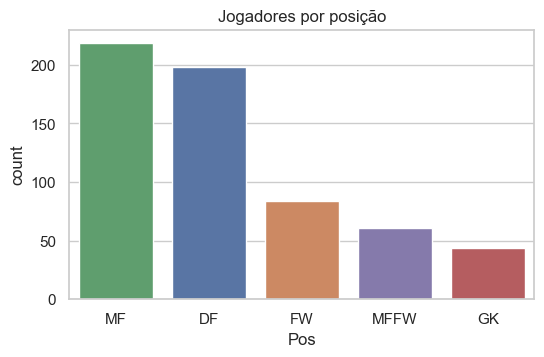

In [26]:
pos_counts = model_df[LABEL_COL].value_counts()
display(pos_counts.to_frame('jogadores').assign(pct=lambda d: (d['jogadores'] / d['jogadores'].sum() * 100).round(1)))

plt.figure(figsize=(6, 3.5))
sns.countplot(data=model_df, x=LABEL_COL, order=pos_counts.index, hue=LABEL_COL, legend=False)
plt.title('Jogadores por posição')
plt.show()

### 3.3 Variáveis de desempenho

São as colunas numéricas que descrevem o estilo de jogo (por jogo): tudo que não é `Pos` nem one-hot de posição.

['Gls', 'Ast', 'CrdY', 'Fls', 'Fld', 'Off', 'Crs', 'Int', 'TklW']


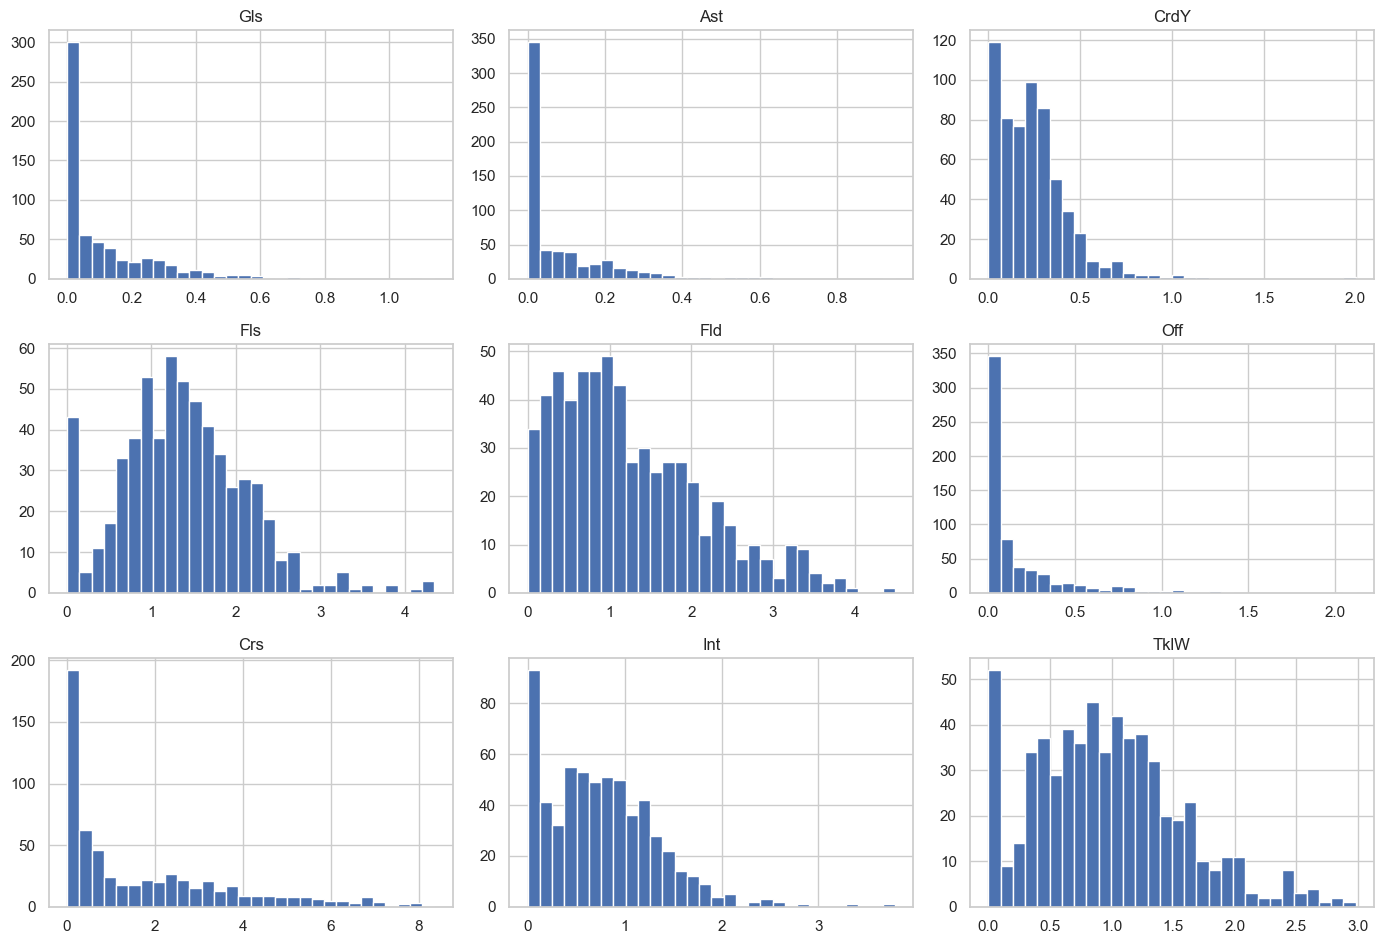

In [27]:
FEATURES = [c for c in model_df.columns if c not in POS_DUMMIES + [LABEL_COL]]
print(FEATURES)

n_rows = int(np.ceil(len(FEATURES) / 3))
model_df[FEATURES].hist(bins=30, figsize=(14, 3.2 * n_rows), layout=(n_rows, 3))
plt.tight_layout()
plt.show()

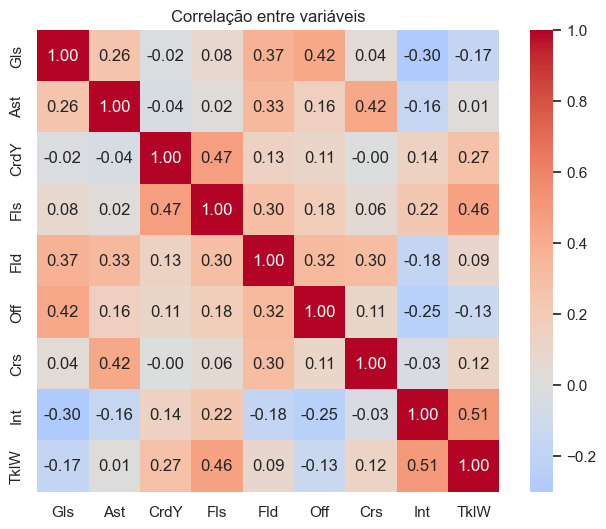

In [28]:
plt.figure(figsize=(8, 6))
sns.heatmap(model_df[FEATURES].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlação entre variáveis')
plt.show()

## 4. Pré-processamento

### 4.1 Seleção de variáveis

O SOM usa distância euclidiana, então só entram as variáveis de desempenho (`FEATURES`). As colunas de posição ficam de fora para o mapa não ser "guiado" pelo rótulo.

In [29]:
X_raw = model_df[FEATURES].copy()
labels = model_df[LABEL_COL].to_numpy()
X_raw.shape

(606, 9)

### 4.2 Tratamento de outliers

O `MinMaxScaler` é sensível a valores extremos: um único jogador muito fora da curva "comprime" todos os outros para perto de 0. Por isso os valores acima do percentil 99 de cada variável são limitados a esse percentil (`CLIP_OUTLIERS = False` desativa).

In [30]:
CLIP_OUTLIERS = True
CLIP_QUANTILE = 0.99

clip_upper = X_raw.quantile(CLIP_QUANTILE) if CLIP_OUTLIERS else None
X_clean = X_raw.clip(upper=clip_upper, axis=1) if CLIP_OUTLIERS else X_raw

if CLIP_OUTLIERS:
    display((X_raw > clip_upper).sum().rename('valores limitados').to_frame().T)

,Gls,Ast,CrdY,Fls,Fld,Off,Crs,Int,TklW
valores limitados,7,7,7,7,7,7,7,6,7


### 4.3 Normalização

Escala cada variável para o intervalo [0, 1], para que nenhuma domine a distância só por ter unidade maior (ex.: `Crs` vs. `Gls`).

In [31]:
scaler = MinMaxScaler()
X = scaler.fit_transform(X_clean)
print(f'shape={X.shape} | min={X.min():.2f} | max={X.max():.2f}')

shape=(606, 9) | min=0.00 | max=1.00


## 5. Funções de treino e avaliação

- **`train_som`**: treina o SOM com inicialização por PCA (determinística e mais estável que a aleatória) e vizinhança gaussiana. Com `track=True` guarda as métricas a cada época.
  - **Decaimento:** o padrão do MiniSom deixa a taxa de aprendizado em ~⅓ do valor inicial no fim e encolhe o `sigma` para bem abaixo de 1, o que faz o erro topográfico subir no final do treino. Aqui a taxa cai até **0** (o treino converge) e o `sigma` cai até **1** (a vizinhança nunca deixa de incluir os vizinhos imediatos).
- **`evaluate_som`**: calcula as duas métricas de qualidade do mapa:
  - **Erro de quantização (QE):** distância média entre cada jogador e seu neurônio vencedor. *Menor é melhor.*
  - **Erro topográfico (TE):** fração de jogadores cujos dois neurônios mais próximos não são vizinhos no mapa. Mede se a topologia foi preservada. *Menor é melhor.*

In [32]:
def suggest_grid_side(n_samples):
    """Heurística de Vesanto: ~5*sqrt(N) neurônios no total (mapa quadrado)."""
    return int(round(np.sqrt(5 * np.sqrt(n_samples))))


def train_som(X, x, y, sigma, learning_rate, epochs, seed=RANDOM_STATE, track=False,
              decay_function=LR_DECAY, sigma_decay_function=SIGMA_DECAY):
    """Treina um SOM e devolve (som, histórico de métricas por época)."""
    som = MiniSom(x, y, X.shape[1], sigma=sigma, learning_rate=learning_rate,
                  neighborhood_function='gaussian', topology='rectangular',
                  decay_function=decay_function, sigma_decay_function=sigma_decay_function,
                  random_seed=seed)
    som.pca_weights_init(X)

    rng = np.random.default_rng(seed)
    total_steps = epochs * len(X)
    history, step = [], 0
    for epoch in range(1, epochs + 1):
        for i in rng.permutation(len(X)):        # ordem aleatória a cada época
            som.update(X[i], som.winner(X[i]), step, total_steps)
            step += 1
        if track:
            history.append({'epoch': epoch,
                            'QE': som.quantization_error(X),
                            'TE': som.topographic_error(X)})
    return som, pd.DataFrame(history)


def evaluate_som(som, X):
    """Retorna (erro de quantização, erro topográfico)."""
    return som.quantization_error(X), som.topographic_error(X)

## 6. Ajuste de hiperparâmetros

Busca em grade sobre:
- **Tamanho do mapa:** heurística `5·√N` neurônios, e mais um mapa menor e um maior.
- **`sigma`:** raio inicial da vizinhança.
- **`learning_rate`:** taxa de aprendizado inicial.

Cada combinação é treinada com 3 sementes e as métricas são **médias**, para não escolher uma configuração só por sorte.

**Critério:** `score = QE normalizado + TE normalizado` (menor é melhor). O QE cai naturalmente em mapas maiores e o TE tende a subir, então o score busca o equilíbrio entre os dois.

In [33]:
base_side = suggest_grid_side(len(X))
GRID_SIDES = sorted({max(6, s) for s in (base_side - 3, base_side, base_side + 3)})
SIGMAS = [1.0, 1.5, 2.0, 3.0]
LEARNING_RATES = [0.1, 0.5, 1.0]
SEARCH_EPOCHS = 30
SEARCH_SEEDS = [0, 1, 2]

records = []
for side, sigma, lr in itertools.product(GRID_SIDES, SIGMAS, LEARNING_RATES):
    qes, tes = [], []
    for seed in SEARCH_SEEDS:
        s, _ = train_som(X, side, side, sigma, lr, SEARCH_EPOCHS, seed=seed)
        qe, te = evaluate_som(s, X)
        qes.append(qe)
        tes.append(te)
    records.append({'grid': side, 'sigma': sigma, 'learning_rate': lr,
                    'QE': np.mean(qes), 'TE': np.mean(tes)})

search_df = pd.DataFrame(records)


def minmax(s):
    denom = s.max() - s.min()
    return (s - s.min()) / denom if denom != 0 else pd.Series(0.0, index=s.index)


search_df['score'] = minmax(search_df['QE']) + minmax(search_df['TE'])
search_df = search_df.sort_values('score').reset_index(drop=True)
search_df.head(10).round(4)

,grid,sigma,learning_rate,QE,TE,score
0,14,2.0,0.1,0.3117,0.0033,0.2165
1,14,3.0,0.5,0.3108,0.0061,0.3415
2,14,3.0,0.1,0.3243,0.0050,0.4459
3,14,2.0,1.0,0.3022,0.0116,0.5104
4,14,1.5,0.1,0.3051,0.0116,0.5447
5,14,1.5,0.5,0.2980,0.0143,0.5964
6,14,1.5,1.0,0.2977,0.0160,0.6741
7,14,1.0,1.0,0.2934,0.0171,0.6776
8,14,2.0,0.5,0.3036,0.0149,0.6890
9,11,3.0,0.1,0.3456,0.0072,0.8045


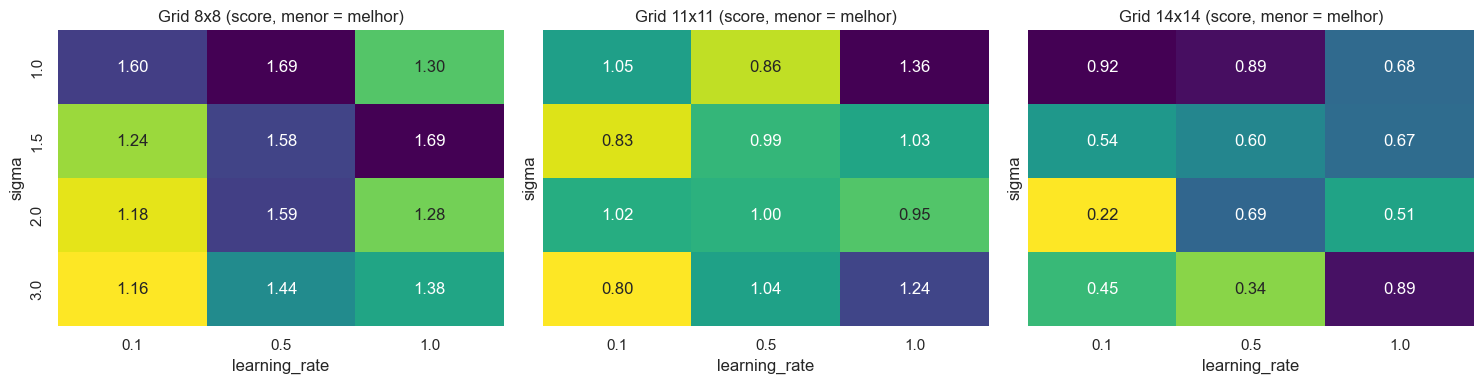

In [34]:
fig, axes = plt.subplots(1, len(GRID_SIDES), figsize=(5 * len(GRID_SIDES), 4), sharey=True)
for ax, side in zip(np.atleast_1d(axes), GRID_SIDES):
    pivot = (search_df[search_df['grid'] == side]
             .pivot(index='sigma', columns='learning_rate', values='score'))
    sns.heatmap(pivot, annot=True, fmt='.2f', cmap='viridis_r', cbar=False, ax=ax)
    ax.set_title(f'Grid {side}x{side} (score, menor = melhor)')
plt.tight_layout()
plt.show()

In [35]:
best = search_df.iloc[0]
BEST_SIDE = int(best['grid'])
BEST_SIGMA = float(best['sigma'])
BEST_LR = float(best['learning_rate'])
print(f'Melhor configuração -> grid {BEST_SIDE}x{BEST_SIDE} | sigma={BEST_SIGMA} | learning_rate={BEST_LR}')

if BEST_SIDE in (min(GRID_SIDES), max(GRID_SIDES)):
    print('Atenção: o melhor tamanho está na borda da busca; considere ampliar GRID_SIDES.')

Melhor configuração -> grid 14x14 | sigma=2.0 | learning_rate=0.1
Atenção: o melhor tamanho está na borda da busca; considere ampliar GRID_SIDES.


## 7. Treinamento final

### 7.1 Treino com a melhor configuração

Treino mais longo (200 épocas) com acompanhamento das métricas para verificar a convergência.

In [36]:
FINAL_EPOCHS = 200

som, history = train_som(X, BEST_SIDE, BEST_SIDE, BEST_SIGMA, BEST_LR,
                         FINAL_EPOCHS, seed=RANDOM_STATE, track=True)
qe, te = evaluate_som(som, X)
print(f'Erro de quantização: {qe:.4f} | Erro topográfico: {te:.4f}')

Erro de quantização: 0.3062 | Erro topográfico: 0.0066


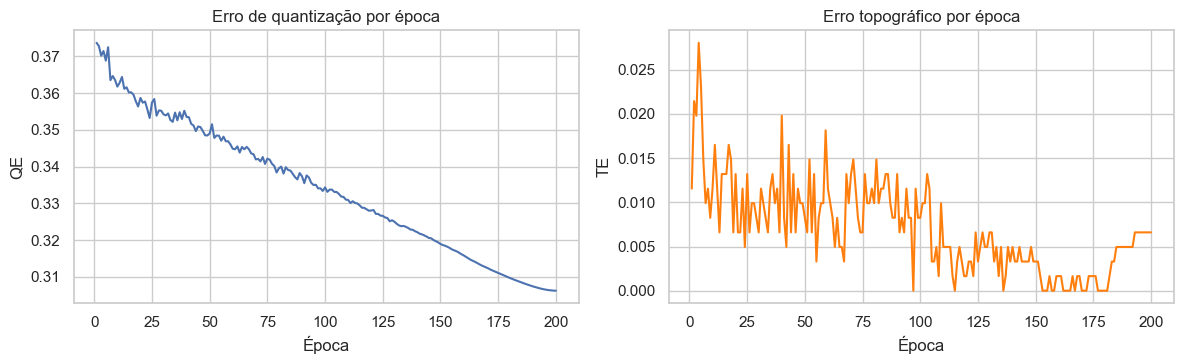

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
axes[0].plot(history['epoch'], history['QE'])
axes[0].set(title='Erro de quantização por época', xlabel='Época', ylabel='QE')
axes[1].plot(history['epoch'], history['TE'], color='tab:orange')
axes[1].set(title='Erro topográfico por época', xlabel='Época', ylabel='TE')
plt.tight_layout()
plt.show()

### 7.2 Estabilidade entre sementes

Treina o mesmo modelo com 5 sementes diferentes. Desvio-padrão baixo indica que o resultado não depende da ordem aleatória dos dados.

In [38]:
stability = []
for seed in range(5):
    s, _ = train_som(X, BEST_SIDE, BEST_SIDE, BEST_SIGMA, BEST_LR, FINAL_EPOCHS, seed=seed)
    stability.append(dict(zip(['QE', 'TE'], evaluate_som(s, X))))

pd.DataFrame(stability).agg(['mean', 'std']).round(4)

,QE,TE
mean,0.3051,0.0063
std,0.0015,0.0022


### 7.3 Decaimento padrão vs. ajustado

Compara o decaimento padrão do MiniSom com o usado neste notebook, na mesma configuração. Esperado: erro topográfico bem menor com o decaimento ajustado, com um erro de quantização um pouco maior (é o custo de preservar a topologia do mapa em vez de ajustar cada neurônio localmente).

In [39]:
compare = []
for name, lr_fn, sigma_fn in [('Padrão do MiniSom', 'asymptotic_decay', 'asymptotic_decay'),
                              ('Ajustado (usado aqui)', LR_DECAY, SIGMA_DECAY)]:
    s, _ = train_som(X, BEST_SIDE, BEST_SIDE, BEST_SIGMA, BEST_LR, FINAL_EPOCHS,
                     decay_function=lr_fn, sigma_decay_function=sigma_fn)
    compare.append({'decaimento': name, **dict(zip(['QE', 'TE'], evaluate_som(s, X)))})

pd.DataFrame(compare).round(4)

,decaimento,QE,TE
0,Padrão do MiniSom,0.2605,0.0446
1,Ajustado (usado aqui),0.3062,0.0066


## 8. Visualização do mapa

### 8.1 U-Matrix e Hit Map

- **U-Matrix:** distância entre neurônios vizinhos. Regiões **escuras** = neurônios muito diferentes dos vizinhos, ou seja, **fronteiras** entre grupos.
- **Hit Map:** quantos jogadores caem em cada neurônio.

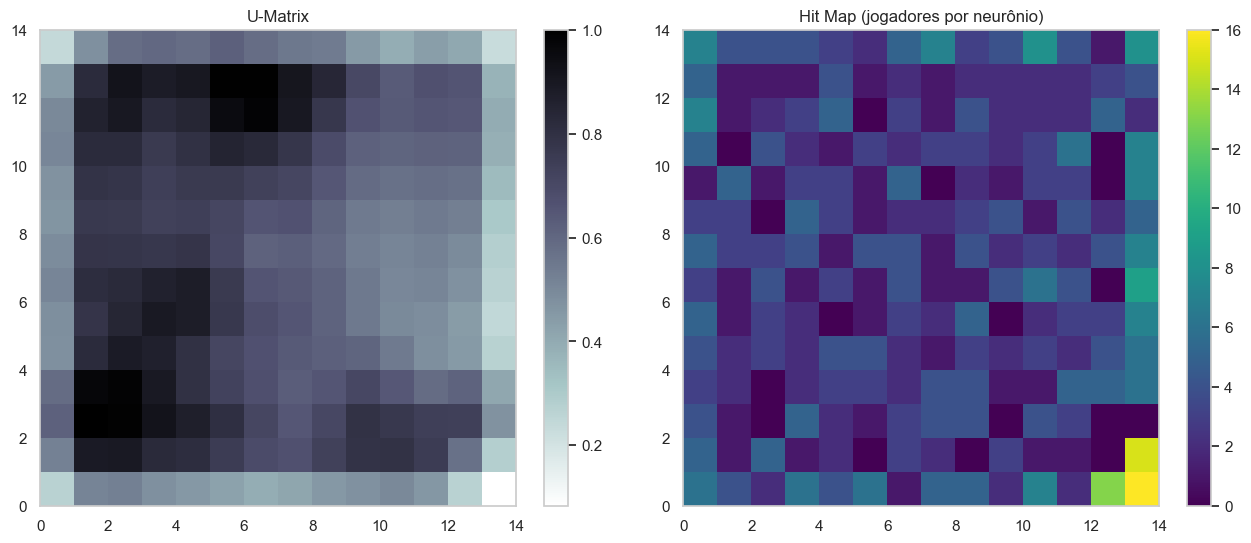

Neurônios sem nenhum jogador: 17 de 196 (9%)


In [40]:
def plot_map(ax, values, title, cmap='viridis'):
    im = ax.pcolor(values.T, cmap=cmap)
    ax.set_title(title)
    ax.set_aspect('equal')
    plt.colorbar(im, ax=ax, fraction=0.046)


hits = som.activation_response(X)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
plot_map(axes[0], som.distance_map(), 'U-Matrix', cmap='bone_r')
plot_map(axes[1], hits, 'Hit Map (jogadores por neurônio)', cmap='viridis')
plt.tight_layout()
plt.show()

print(f'Neurônios sem nenhum jogador: {(hits == 0).sum()} de {hits.size} ({(hits == 0).mean():.0%})')

### 8.2 Component Planes

Um mapa por variável, mostrando o valor (normalizado) que cada neurônio aprendeu. Comparar os mapas ajuda a entender **o que cada região representa** (ex.: região com `Gls` alto e `Int` baixo = perfil ofensivo).

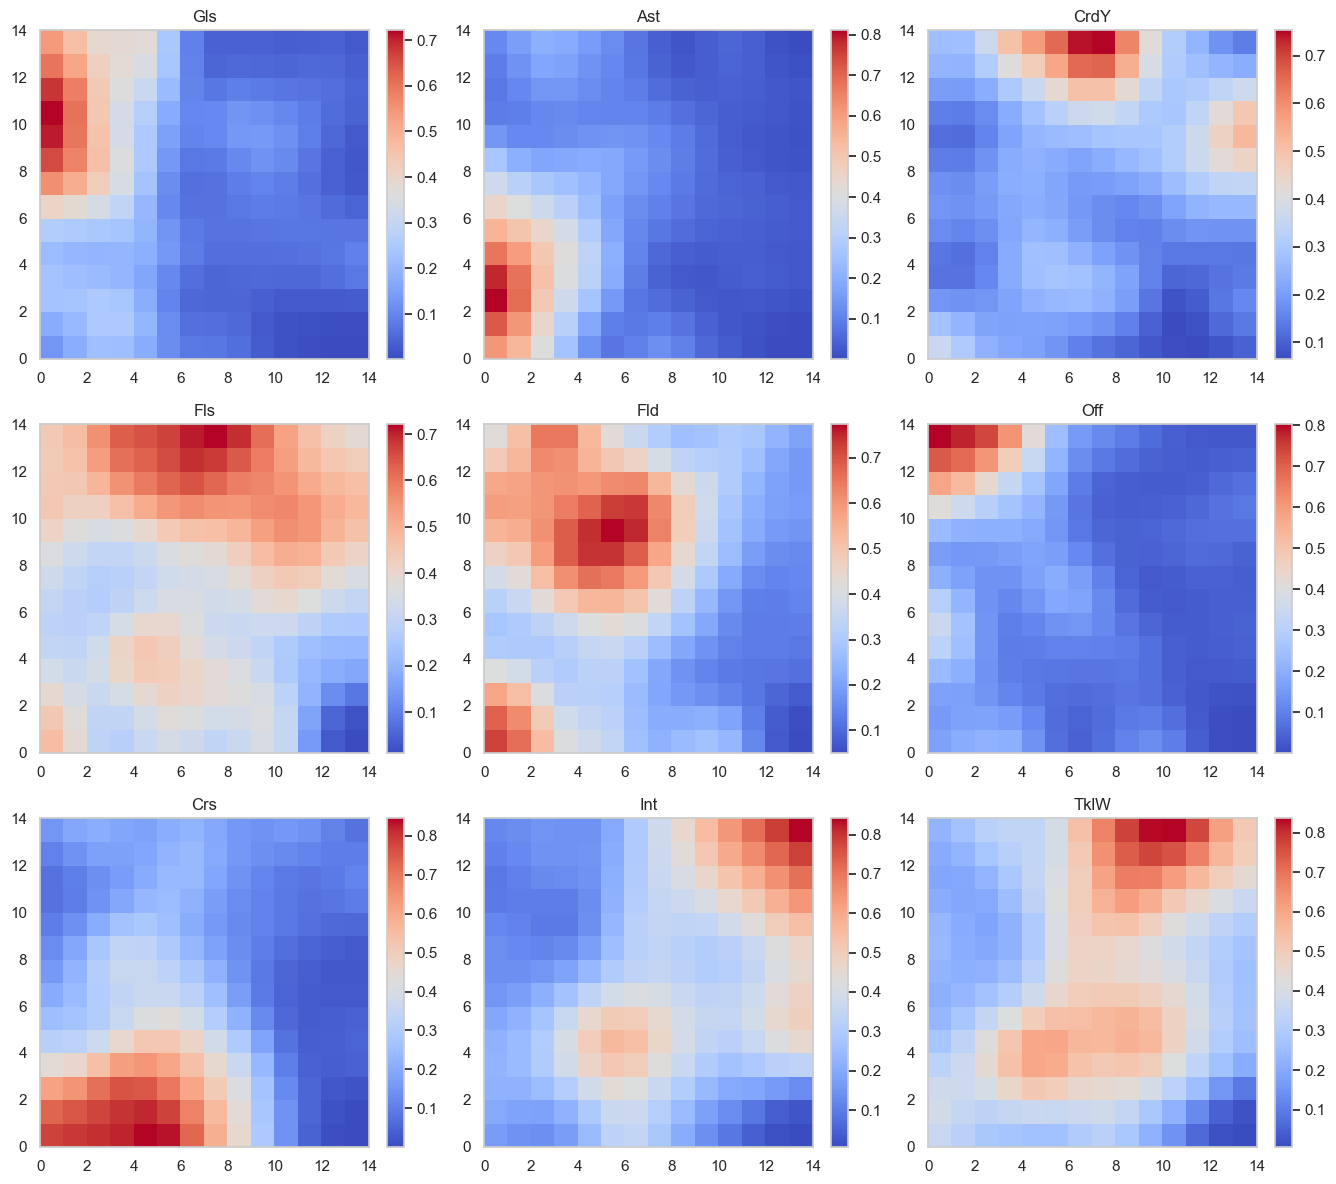

In [41]:
weights = som.get_weights()          # (x, y, n_features)
n_cols = 3
n_rows = int(np.ceil(len(FEATURES) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.5 * n_cols, 4 * n_rows))
axes = axes.ravel()
for i, name in enumerate(FEATURES):
    plot_map(axes[i], weights[:, :, i], name, cmap='coolwarm')
for ax in axes[len(FEATURES):]:
    ax.axis('off')
plt.tight_layout()
plt.show()

### 8.3 Mapa de posições

Cada neurônio recebe a **posição majoritária** dos jogadores que caíram nele. A **pureza do mapa** é a fração de jogadores cuja posição coincide com a do seu neurônio (1.0 = separação perfeita).

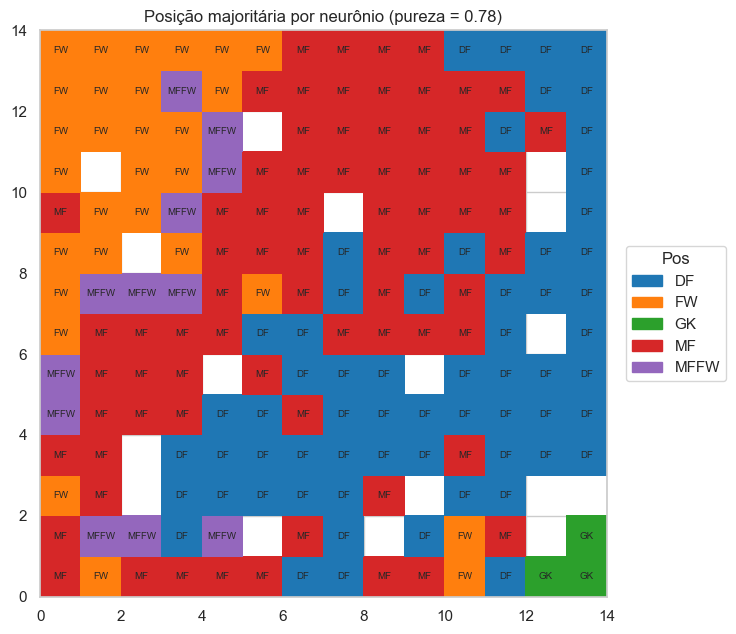

In [42]:
neuron_labels = defaultdict(list)
for xi, lab in zip(X, labels):
    neuron_labels[som.winner(xi)].append(lab)

classes = sorted(pd.unique(labels))
class_id = {c: i for i, c in enumerate(classes)}

majority = np.full((BEST_SIDE, BEST_SIDE), np.nan)
majority_text = {}
correct = 0
for (i, j), labs in neuron_labels.items():
    top_label, top_count = Counter(labs).most_common(1)[0]
    majority[i, j] = class_id[top_label]
    majority_text[(i, j)] = top_label
    correct += top_count

map_purity = correct / len(X)

colors = sns.color_palette('tab10', len(classes))
fig, ax = plt.subplots(figsize=(7.5, 6.5))
ax.pcolor(np.ma.masked_invalid(majority).T, cmap=ListedColormap(colors),
          vmin=-0.5, vmax=len(classes) - 0.5)
for (i, j), text in majority_text.items():
    ax.text(i + 0.5, j + 0.5, text, ha='center', va='center', fontsize=7)
ax.set_aspect('equal')
ax.set_title(f'Posição majoritária por neurônio (pureza = {map_purity:.2f})')
ax.legend(handles=[Patch(color=colors[i], label=c) for i, c in enumerate(classes)],
          loc='center left', bbox_to_anchor=(1.02, 0.5), title=LABEL_COL)
plt.tight_layout()
plt.show()

## 9. Clusterização do mapa

Com dezenas de neurônios, o mapa é detalhado demais para interpretar. Por isso os neurônios são agrupados em poucos **clusters** com KMeans sobre os pesos (codebook).

- Cada neurônio é ponderado pelo número de jogadores que ele recebeu, para que neurônios vazios não distorçam os centros.
- O número de clusters `k` é escolhido por **silhouette** (maior é melhor) e **Davies-Bouldin** (menor é melhor), calculados sobre os jogadores. O intervalo começa em 3 para evitar divisões triviais demais.

In [43]:
n_neurons = BEST_SIDE * BEST_SIDE
codebook = som.get_weights().reshape(n_neurons, -1)       # (neurônios, variáveis)

bmu_xy = np.array([som.winner(xi) for xi in X])            # neurônio vencedor de cada jogador
bmu_index = np.ravel_multi_index((bmu_xy[:, 0], bmu_xy[:, 1]), (BEST_SIDE, BEST_SIDE))
neuron_hits = np.bincount(bmu_index, minlength=n_neurons)  # jogadores por neurônio

K_RANGE = range(3, 9)
k_records = []
for k in K_RANGE:
    km = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE).fit(codebook, sample_weight=neuron_hits)
    player_clusters = km.labels_[bmu_index]
    k_records.append({'k': k,
                      'silhouette': silhouette_score(X, player_clusters),
                      'davies_bouldin': davies_bouldin_score(X, player_clusters)})

k_df = pd.DataFrame(k_records)
k_df.round(4)

C:\Users\joaop\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] O sistema não pode encontrar o arquivo especificado
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\joaop\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^

,k,silhouette,davies_bouldin
0,3,0.1541,1.6711
1,4,0.1759,1.6261
2,5,0.1624,1.7144
3,6,0.1624,1.7530
4,7,0.1535,1.7345
5,8,0.1569,1.7075


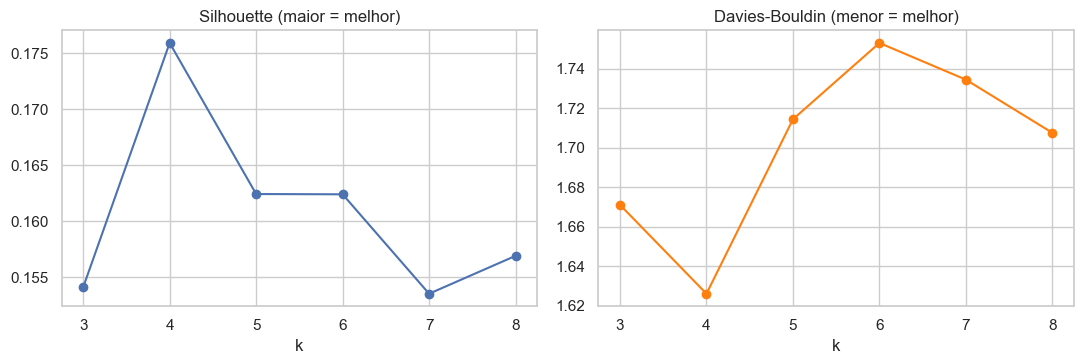

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].plot(k_df['k'], k_df['silhouette'], marker='o')
axes[0].set(title='Silhouette (maior = melhor)', xlabel='k')
axes[1].plot(k_df['k'], k_df['davies_bouldin'], marker='o', color='tab:orange')
axes[1].set(title='Davies-Bouldin (menor = melhor)', xlabel='k')
plt.tight_layout()
plt.show()

### 9.1 Clusters finais

`K_FINAL = None` usa o `k` de maior silhouette. Defina um inteiro (ex.: `K_FINAL = 4`) para forçar outro valor.

In [45]:
K_FINAL = None

best_k = int(k_df.loc[k_df['silhouette'].idxmax(), 'k']) if K_FINAL is None else K_FINAL
kmeans = KMeans(n_clusters=best_k, n_init=20, random_state=RANDOM_STATE).fit(codebook, sample_weight=neuron_hits)
neuron_cluster = kmeans.labels_.reshape(BEST_SIDE, BEST_SIDE)

results_df = model_df.copy()
results_df['bmu_x'] = bmu_xy[:, 0]
results_df['bmu_y'] = bmu_xy[:, 1]
results_df['cluster'] = kmeans.labels_[bmu_index]

print(f'k escolhido: {best_k}')

k escolhido: 4


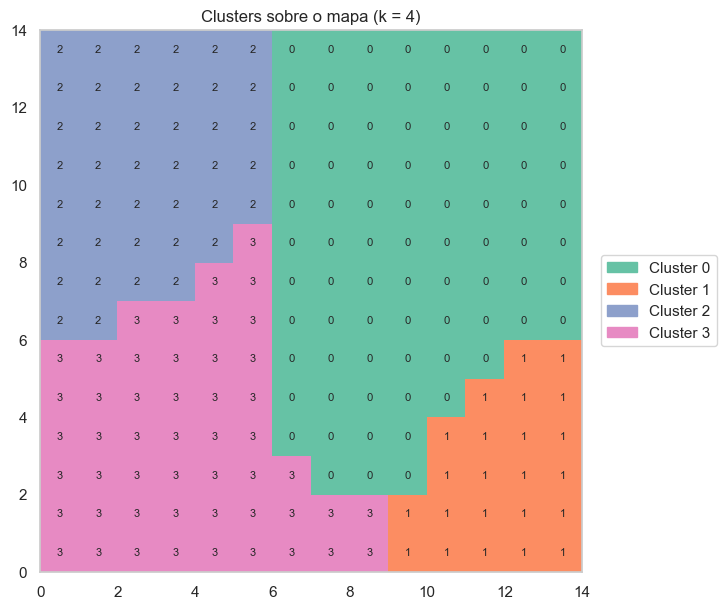

In [46]:
cluster_colors = sns.color_palette('Set2', best_k)
fig, ax = plt.subplots(figsize=(7, 6.5))
ax.pcolor(neuron_cluster.T, cmap=ListedColormap(cluster_colors), vmin=-0.5, vmax=best_k - 0.5)
for i in range(BEST_SIDE):
    for j in range(BEST_SIDE):
        ax.text(i + 0.5, j + 0.5, neuron_cluster[i, j], ha='center', va='center', fontsize=8)
ax.set_aspect('equal')
ax.set_title(f'Clusters sobre o mapa (k = {best_k})')
ax.legend(handles=[Patch(color=cluster_colors[c], label=f'Cluster {c}') for c in range(best_k)],
          loc='center left', bbox_to_anchor=(1.02, 0.5))
plt.tight_layout()
plt.show()

## 10. Interpretação dos clusters

### 10.1 Perfil médio de cada cluster

Médias na escala original. O heatmap mostra quantos desvios-padrão cada cluster está **acima (vermelho)** ou **abaixo (azul)** da média geral em cada variável.

In [47]:
cluster_sizes = results_df['cluster'].value_counts().sort_index().rename('jogadores')
cluster_profile = results_df.groupby('cluster')[FEATURES].mean()

display(cluster_sizes.to_frame())
display(cluster_profile.round(2))

,jogadores
cluster,
0,250
1,106
2,117
3,133


,Gls,Ast,CrdY,Fls,Fld,Off,Crs,Int,TklW
cluster,,,,,,,,,
0,0.04,0.03,0.31,1.66,1.07,0.06,1.11,1.13,1.33
1,0.02,0.01,0.10,0.54,0.42,0.03,0.33,0.44,0.39
2,0.33,0.09,0.25,1.60,2.08,0.42,1.40,0.29,0.66
3,0.11,0.21,0.20,1.27,1.51,0.16,4.38,0.71,0.99


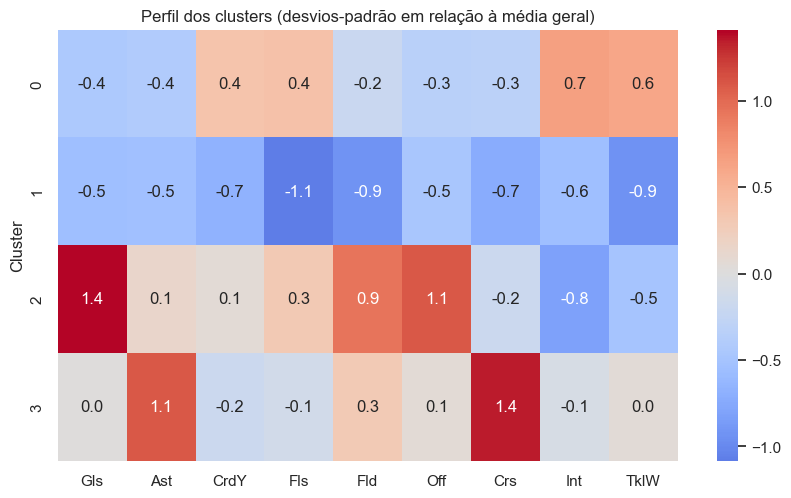

In [48]:
z_profile = (cluster_profile - results_df[FEATURES].mean()) / results_df[FEATURES].std()

plt.figure(figsize=(10, 0.9 * best_k + 2))
sns.heatmap(z_profile, annot=True, fmt='.1f', cmap='coolwarm', center=0)
plt.title('Perfil dos clusters (desvios-padrão em relação à média geral)')
plt.ylabel('Cluster')
plt.show()

### 10.2 Clusters × posição real

Percentual de cada cluster que pertence a cada posição. Não é esperado que seja perfeito: o SOM agrupa por **estilo de jogo**, e jogadores da mesma posição podem ter estilos diferentes.

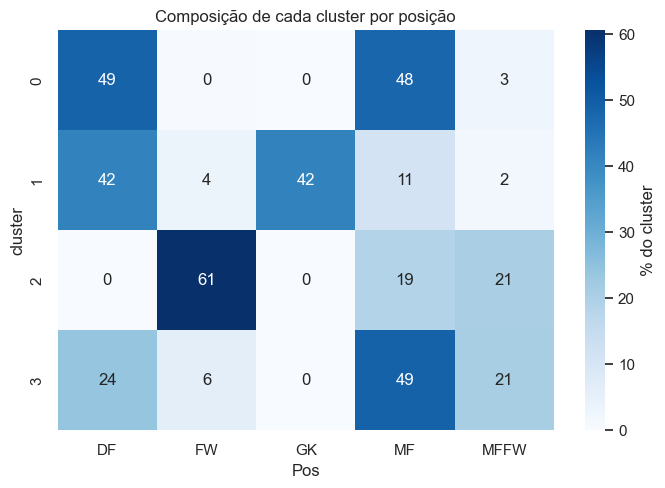

In [49]:
crosstab = pd.crosstab(results_df['cluster'], results_df[LABEL_COL], normalize='index') * 100

plt.figure(figsize=(8, 0.8 * best_k + 2))
sns.heatmap(crosstab, annot=True, fmt='.0f', cmap='Blues', cbar_kws={'label': '% do cluster'})
plt.title('Composição de cada cluster por posição')
plt.show()

### 10.3 Resumo das métricas

- **QE / TE:** qualidade do mapa (menor é melhor).
- **Pureza:** concordância entre neurônio e posição.
- **Silhouette / Davies-Bouldin:** qualidade dos clusters.
- **ARI / NMI:** concordância entre clusters e posições (0 = aleatório, 1 = idêntico).

In [50]:
final_qe, final_te = evaluate_som(som, X)
final_clusters = results_df['cluster']

summary = pd.Series({
    'QE': final_qe,
    'TE': final_te,
    'Pureza do mapa': map_purity,
    'Silhouette': silhouette_score(X, final_clusters),
    'Davies-Bouldin': davies_bouldin_score(X, final_clusters),
    'ARI (cluster x Pos)': adjusted_rand_score(results_df[LABEL_COL], final_clusters),
    'NMI (cluster x Pos)': normalized_mutual_info_score(results_df[LABEL_COL], final_clusters),
}, name='valor')
summary.round(4).to_frame()

,valor
QE,0.3062
TE,0.0066
Pureza do mapa,0.7805
Silhouette,0.1759
Davies-Bouldin,1.6261
ARI (cluster x Pos),0.2264
NMI (cluster x Pos),0.3201


## 11. Exportação e uso do modelo

### 11.1 Salvando modelo e resultados

O `pickle` guarda tudo que é necessário para reaplicar o modelo: SOM, scaler, KMeans, limites de outliers e parâmetros.

In [51]:
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
RESULTS_PATH.parent.mkdir(parents=True, exist_ok=True)

artifacts = {
    'som': som,
    'scaler': scaler,
    'kmeans': kmeans,
    'features': FEATURES,
    'clip_upper': clip_upper,
    'params': {'grid': BEST_SIDE, 'sigma': BEST_SIGMA, 'learning_rate': BEST_LR,
               'epochs': FINAL_EPOCHS, 'k': best_k, 'random_state': RANDOM_STATE},
}
with open(MODEL_PATH, 'wb') as f:
    pickle.dump(artifacts, f)

results_df.to_csv(RESULTS_PATH, index=False)
print(f'Modelo salvo em: {MODEL_PATH}')
print(f'Resultados salvos em: {RESULTS_PATH}')

Modelo salvo em: ..\..\models\som_players.pkl
Resultados salvos em: ..\..\data\processed\player-stats-som-clusters.csv


### 11.2 Classificando novos jogadores

Recebe um DataFrame com as colunas de `FEATURES` e devolve o cluster de cada jogador, aplicando os mesmos passos do treino (limite de outliers → normalização → neurônio vencedor → cluster).

In [52]:
def predict_cluster(new_df):
    """Devolve o cluster de cada jogador de `new_df` (precisa conter as colunas FEATURES)."""
    data = new_df[FEATURES]
    if clip_upper is not None:
        data = data.clip(upper=clip_upper, axis=1)
    data = scaler.transform(data)
    bmus = [np.ravel_multi_index(som.winner(row), (BEST_SIDE, BEST_SIDE)) for row in data]
    return kmeans.labels_[bmus]


# Conferência: deve reproduzir os clusters já calculados
predict_cluster(model_df.head())

array([0, 2, 3, 0, 0])

## Próximos passos

- Testar `topology='hexagonal'` no `MiniSom` (vizinhança mais uniforme).
- Avaliar goleiros (`GK`) separadamente: têm estatísticas próximas de zero e tendem a ocupar uma região isolada do mapa.
- Adicionar variáveis como minutos jogados, finalizações e passes, se disponíveis.
- Comparar os clusters do SOM com KMeans direto nos dados, como referência.